In [1]:
# Import TensorFlow library
import tensorflow

# Import the Keras module from TensorFlow
from tensorflow import keras

# Import Sequential class to create a linear stack of layers for a neural network
from tensorflow.keras import Sequential

# Import the layers we need:
# Input      - declares the shape of one sample (28x28 image)
# Reshape    - adds a channel dimension so the augmentation layers can work
# Flatten    - turns the 2D image into a 1D array of 784 values
# Dense      - fully connected layer
# Dropout    - randomly switches off neurons during training, which fights overfitting
# BatchNormalization - keeps layer outputs well scaled so training is faster and more stable
# RandomTranslation / RandomZoom - shift and zoom the digit slightly during training only,
#   so the model learns that a digit is still a digit when it is not perfectly centred
from tensorflow.keras.layers import (Input, Reshape, Flatten, Dense, Dropout,
                                     BatchNormalization, RandomTranslation, RandomZoom)


In [2]:
# Load the MNIST dataset using Keras's built-in utility
# The dataset contains handwritten digit images (28x28 pixels) and their labels (0-9)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# X_train and y_train are the training data and corresponding labels
# X_test and y_test are the test data and corresponding labels

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

In [4]:
# Check the shape of the test dataset (X_test)
# This will return a tuple indicating the dimensions of the dataset (number of samples, height, width)
X_test.shape

(10000, 28, 28)

In [5]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

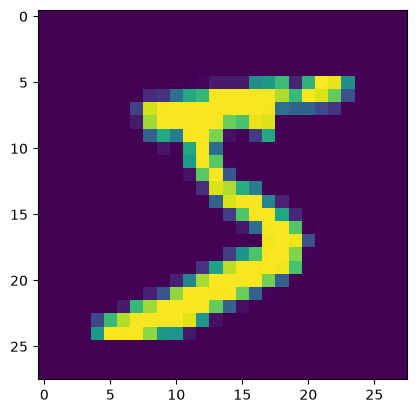

In [9]:
# Import the matplotlib library for visualization
import matplotlib.pyplot as plt

# Display the third image from the training dataset (X_train) using imshow
# imshow is used to display an image in a 2D array (grayscale or color)
plt.imshow(X_train[0])

In [10]:
 # Normalize the pixel values of the training dataset (X_train) to the range 0-1
# This is done by dividing each pixel value by 255 (the maximum pixel intensity in an image)
X_train = X_train / 255

# Normalize the pixel values of the test dataset (X_test) to the range 0-1
# Normalization helps in faster training and better convergence of the neural network
X_test = X_test / 255

In [11]:
# Access the first image in the training dataset (X_train)
# This will display the pixel values of the first 28x28 image as a 2D array
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [13]:
# Build the network as a linear stack of layers
model = Sequential([

    # Declare the input: one 28x28 grayscale image
    Input(shape=(28, 28)),

    # --- Data augmentation (active during training only, ignored when predicting) ---
    # Add a channel dimension: (28, 28) -> (28, 28, 1), which these layers require
    #Reshape — just a technical step. The image is 28×28, but the augmentation layers need it in the format 28×28×1
    #(the "1" means grayscale, one color channel). No visual change at all.
    Reshape((28, 28, 1)),
    # Randomly shift the digit up to 10% of the image in each direction
    # RandomTranslation(0.1, 0.1) — randomly shifts the digit left/right/up/down by up to 10%. So if the digit "5" was perfectly centered, 
    # sometimes the model sees it shifted a little to the left, sometimes a little down, etc.
    RandomTranslation(0.1, 0.1),
    # Randomly zoom in or out by up to 10%
    # RandomZoom(0.1) — randomly zooms in or out by up to 10%. So sometimes the "5" looks slightly bigger, 
    # sometimes slightly smaller
    RandomZoom(0.1),

    # Flatten the image into a 1D array of 28*28 = 784 values
    Flatten(),

    # Hidden layer 1: wide enough to learn a rich set of pen-stroke features
    
     # BatchNormalization — imagine each layer is passing numbers to the next layer. Sometimes those numbers get really big (like 500, 1000) or really small (like 0.0001). 
    # This makes the next layer's job harder — it's like trying to learn when the teacher keeps changing the language every 5 minutes. 
    # BatchNorm fixes this by keeping the numbers in a consistent, stable range after every layer. Result: training is faster and more stable.

    # Dropout(0.2) — during training, it randomly switches off 20% of neurons in that layer for each batch. 
    # Different neurons get switched off each time.

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden layer 2
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden layer 3
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Output layer: 10 neurons (digits 0-9), softmax turns them into probabilities
    Dense(10, activation='softmax'),
])

In [14]:
# Display a summary of the model architecture
# This provides information about each layer, the output shape, the number of parameters, and the total parameters in the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [15]:
# Compile the model by specifying the loss function, optimizer, and evaluation metrics
# loss: 'sparse_categorical_crossentropy' is used for multi-class classification when labels are integers
# optimizer: Adam with an explicit learning rate of 0.001 (the usual good starting point)
# metrics: 'accuracy' is used to evaluate the performance of the model during training and testing
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])


In [16]:
# Two callbacks that tune the training for us instead of guessing a fixed epoch count:
#
# EarlyStopping    - stop once validation accuracy has not improved for 5 epochs, and
#                    restore the best weights we saw. This prevents overfitting and
#                    means we can safely ask for more epochs than we probably need.
# ReduceLROnPlateau - when validation loss stalls, halve the learning rate so the model
#                    can settle into a better minimum instead of bouncing around.
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=3, min_lr=1e-5),
]

# Train the model
# epochs=40        : an upper bound - EarlyStopping will usually stop around epoch 30
# batch_size=128   : how many images the model looks at before each weight update
# validation_split : hold back 10% of the training data to monitor performance
history = model.fit(X_train, y_train,
                    epochs=40,
                    batch_size=128,
                    validation_split=0.1,
                    callbacks=callbacks)


Epoch 1/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8329 - loss: 0.5294 - val_accuracy: 0.9627 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 2/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9192 - loss: 0.2591 - val_accuracy: 0.9735 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 3/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9352 - loss: 0.2085 - val_accuracy: 0.9740 - val_loss: 0.0827 - learning_rate: 0.0010
Epoch 4/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9439 - loss: 0.1808 - val_accuracy: 0.9737 - val_loss: 0.0775 - learning_rate: 0.0010
Epoch 5/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9483 - loss: 0.1655 - val_accuracy: 0.9765 - val_loss: 0.0720 - learning_rate: 0.0010
Epoch 6/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9527 - loss: 0.1523 - val_accuracy: 0.9780 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 7/40
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9544 - loss: 0

In [17]:
# Save the trained model in Keras' native format.
# Use this file in the Streamlit app (digit-app) to test your own model.
model.save('my_first_trained_model_3.keras')

# On Google Colab, download it to your computer:
# from google.colab import files
# files.download('my_first_trained_model.keras')


In [18]:
# Use the trained model to make predictions on the test data (X_test)
# y_prob will contain the predicted probabilities for each class (0-9) for each test image
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [19]:
y_prob

array([[1.9531689e-07, 5.2732491e-07, 3.4724742e-06, ..., 9.9999261e-01,
        1.7828594e-08, 2.0106668e-06],
       [3.2116205e-07, 2.2497876e-05, 9.9994326e-01, ..., 9.9296376e-06,
        7.5993244e-06, 1.8400233e-07],
       [7.0513024e-06, 9.9973184e-01, 3.3039773e-06, ..., 6.8430731e-05,
        2.1111113e-05, 7.7872988e-07],
       ...,
       [3.6997858e-07, 6.4567294e-06, 6.9777812e-08, ..., 6.6043895e-06,
        6.7101433e-07, 6.2286872e-06],
       [3.9827999e-08, 1.7102375e-09, 2.4094400e-09, ..., 1.5923862e-07,
        8.6266718e-06, 7.8783921e-07],
       [3.0640560e-05, 4.5475093e-07, 1.1189466e-05, ..., 6.5059034e-09,
        1.2458354e-06, 4.5522521e-07]], shape=(10000, 10), dtype=float32)

In [23]:
# Convert the predicted probabilities (y_prob) into class labels
# argmax(axis=1) returns the index of the maximum probability for each sample, which corresponds to the predicted class label
y_pred = y_prob.argmax(axis=1)

In [24]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [25]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.981

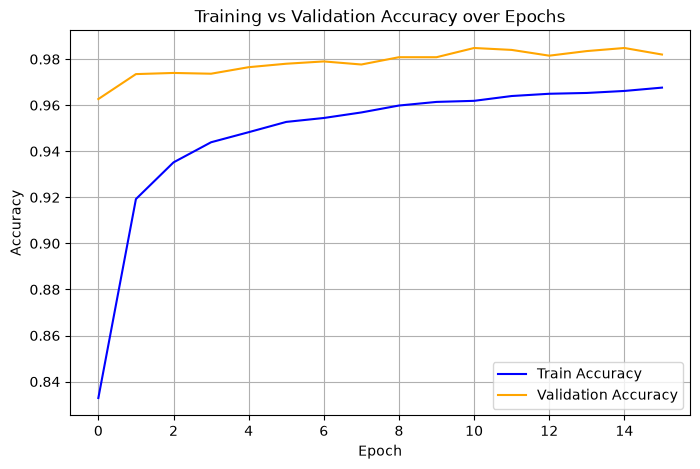

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


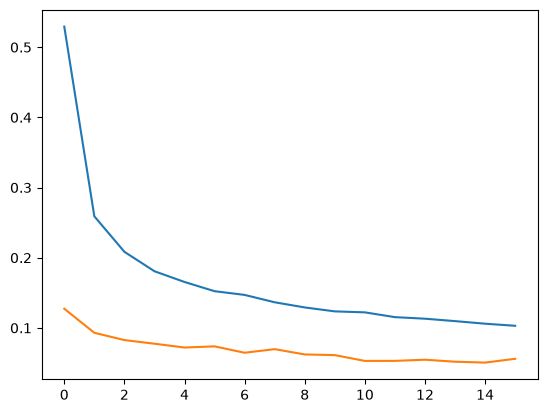

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

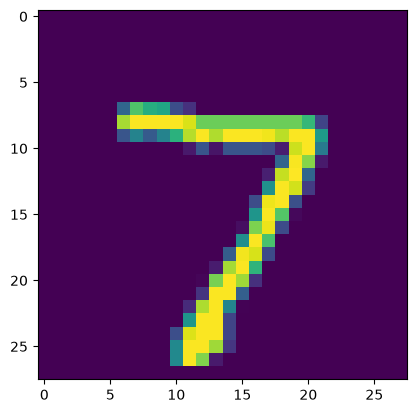

In [32]:
plt.imshow(X_test[0])



In [33]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([2])

In [34]:
#from google.colab import drive
#drive.mount('/content/drive')

Image array shape: (28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


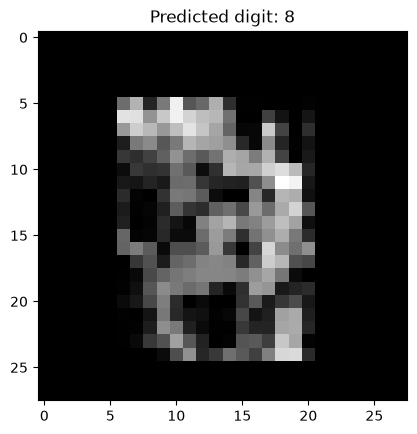

The predicted digit is: 8


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from scipy import ndimage

# Load the model if it's not already loaded
model = keras.models.load_model('C:/Users/ACER/OneDrive/Desktop/AI ML notes/AI-GenAI-labs/06-Mlp/Project/my_first_trained_model_3.keras')

# Load the image you want to test
img_path = 'C:/Users/ACER/OneDrive/Desktop/AI ML notes/AI-GenAI-labs/four.jfif'  # Replace with the path to your image file


def prepare_image(pil_image):
    """Turn a photo of a handwritten digit into the 28x28 input the model expects.

    A phone photo looks nothing like MNIST, so there is real work to do here.
    """
    gray = pil_image.convert("L")
    a = np.asarray(gray, dtype=np.float32)
    big = max(gray.size)

    def ink(radius):
        """Whatever is DARKER than its own local background is ink.

        Blurring the photo estimates what the blank page looks like: the blur
        erases the pen strokes but keeps shadows and uneven lighting. Comparing
        against that also handles the inversion, since a photo is dark ink on
        white paper while MNIST is a white digit on black.
        """
        bg = np.asarray(gray.filter(ImageFilter.GaussianBlur(radius)), dtype=np.float32)
        return np.clip(bg - a, 0, None)

    # The blur radius has to be bigger than the pen stroke, or the "background"
    # eats into the stroke and hollows it out. But too big and it stops tracking
    # a sharp shadow edge. So measure the stroke first, then size the radius to it.
    rough = ink(big / 12.0)
    if rough.max() == 0:
        return np.zeros((28, 28), np.float32)
    rough_mask = rough > 0.4 * rough.max()
    if not rough_mask.any():
        return np.zeros((28, 28), np.float32)
    stroke = 2.0 * np.percentile(ndimage.distance_transform_edt(rough_mask)[rough_mask], 90)
    a = ink(float(np.clip(3.0 * stroke, big / 60.0, big / 3.0)))

    if a.max() == 0:
        return np.zeros((28, 28), np.float32)

    # Keep only the biggest connected blob of ink. That is the digit - ruled
    # paper lines, smudges and dust specks get dropped here.
    mask = a > 0.35 * a.max()
    labels, n = ndimage.label(mask)
    if n > 1:
        sizes = ndimage.sum(mask, labels, range(1, n + 1))
        mask = labels == (1 + int(np.argmax(sizes)))
    if not mask.any():
        return np.zeros((28, 28), np.float32)

    # Crop tight to the digit, then rebuild the MNIST framing ourselves: scale the
    # longest side to 20px and paste it centred into a 28x28 box. Taking the margin
    # from the photo instead would fail whenever someone zooms right in.
    ys, xs = np.where(mask)
    a = a[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    a = a / a.max() * 255.0

    h, w = a.shape
    scale = 20.0 / max(h, w)
    nh, nw = max(1, int(round(h * scale))), max(1, int(round(w * scale)))
    small = np.asarray(Image.fromarray(a.astype(np.uint8)).resize((nw, nh), Image.LANCZOS),
                       dtype=np.float32)

    out = np.zeros((28, 28), np.float32)
    top, left = (28 - nh) // 2, (28 - nw) // 2
    out[top:top + nh, left:left + nw] = small

    # MNIST digits sit at their centre of mass, not the centre of their box.
    total = out.sum()
    if total > 0:
        idx = np.arange(28)
        dy = int(round(13.5 - out.sum(1) @ idx / total))
        dx = int(round(13.5 - out.sum(0) @ idx / total))
        shifted = np.zeros_like(out)
        y0, y1 = max(0, dy), 28 + min(0, dy)
        x0, x1 = max(0, dx), 28 + min(0, dx)
        shifted[y0:y1, x0:x1] = out[y0 - dy:y1 - dy, x0 - dx:x1 - dx]
        out = shifted

    return out / max(out.max(), 1e-6)


img_array = prepare_image(Image.open(img_path))
print("Image array shape:", img_array.shape)

# Predict the digit
y_prob = model.predict(img_array.reshape(1, 28, 28))  # Get the prediction probabilities
y_pred = y_prob.argmax(axis=1)  # Get the predicted class label (digit)

# Show the image the way the MODEL sees it, not the way the file looks.
# It should be a white digit on a black background, with a clear margin around
# it. If it is not, the prediction will be wrong - fix the photo, not the model.
plt.imshow(img_array, cmap='gray')
plt.title(f'Predicted digit: {y_pred[0]}')
plt.show()

# Print the predicted digit
print(f'The predicted digit is: {y_pred[0]}')


# Project Work

In [ ]:
# Project: Fashion Item Classifier

# Build a Streamlit app that predicts what clothing item is in a photo.

# Requirements:

# Train an MLP on tf.keras.datasets.fashion_mnist
# Save the model
# Build a Streamlit app where you upload an image of a clothing item
# Show the predicted class name and confidence
# Show the bar chart of all 10 class probabilities

# Hints:

# The 10 classes are: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
# The image needs to be converted to grayscale, resized to 28x28, and normalized
# Use st.file_uploader with type=["png", "jpg", "jpeg"] instead of the canvas